# Goal 2: The Autonomous Compliance Sentinel
### Baseline model · Risk analysis · Fairness analysis

This notebook builds on **Goal 1** (data, policy catalog RAI-01…09, architecture,
regulatory analysis) and delivers the three Goal 2 milestones:

1. **Build a baseline model** - two transparent ML baselines that decide
   *Compliant* vs. *Red Flag* from a proposal's text.
2. **Make a risk analysis** - what can go wrong, how likely/severe, mitigation, and
   **how we test it**.
3. **Analyze fairness** - does the Sentinel enforce the rules equally across groups?

## Setup

In [1]:
import os, sys, warnings
sys.path.insert(0, os.getcwd()) 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sentinel as S                                # our reusable package
from sentinel import metrics as MET

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
print("sentinel version:", S.__version__)

sentinel version: 1.0


## 1. Load data & build artifacts

sentinel.build_artifacts() runs the whole reproducible pipeline in one call:
load the 1000 proposals from Goal 1 → stratified split → train both baselines →
evaluate on the hold-out → persist models, split and test predictions into
'artifacts/'.

In [2]:
art = S.build_artifacts()
df           = art["df"]
idx_train    = art["idx_train"]
idx_test     = art["idx_test"]
models       = art["models"]            # tfidf+logreg vs tfidf+nb
scores       = art["scores"]
fair_frames  = art["fair_frames"]

print(f"Loaded {len(df)} proposals · train {len(idx_train)} / test {len(idx_test)}")
print(f"Red-Flag prevalence: {df[S.TARGET_COLUMN].mean():.1%}")
print("Saved artifacts:", sorted(os.listdir(art['artifact_dir'])))

Loaded 1000 proposals · train 800 / test 200
Red-Flag prevalence: 33.3%
Saved artifacts: ['model_tfidf_logreg.joblib', 'model_tfidf_nb.joblib', 'scores.csv', 'split.joblib', 'test_predictions_logreg.csv']


### Target and grouping columns

- **input:** 'description' (free text) → **target:** 'Red Flag' (=1) vs 'Compliant' (=0).
- 'red_flags'/'n_red_flags' hold the RAI codes (analysis only, never an input).
- grouping for fairness: 'ai_method', 'issue_type', 'grounded_flag'
  (1 = violation phrased from a **real** NFR sentence, 0 = synthetic).

In [3]:
print(df["label"].value_counts(), "\n")
X_test, y_test = S.get_xy(df, idx_test)

label
Compliant    667
Red Flag     333
Name: count, dtype: int64 



## 2. Baseline models

From **simple to reasonable**, so any later model must beat a documented reference:

1. **Majority class** - always *Compliant*: the accuracy floor.
2. **Keyword rules** - a tiny, transparent RAI rule list (no ML).
3. **TF-IDF + Logistic Regression** - primary baseline (balanced classes).
4. **TF-IDF + Naive Bayes** - a second, contrasting model family.

Items 3–4 are the two real models Goal 3 will analyse and explain (XAI).

### 2.1 Trivial + rule baselines

In [4]:
y_majority = S.majority_predict(len(y_test))
y_rule     = S.rule_predict(X_test)

print("Majority class  -> recall on Red Flags:",
      round(MET.binary_scores(y_test, y_majority)["recall"], 3), "(catches ZERO)")
print("Keyword rules   -> recall:",
      round(MET.binary_scores(y_test, y_rule)["recall"], 3),
      "| precision:", round(MET.binary_scores(y_test, y_rule)["precision"], 3))

Majority class  -> recall on Red Flags: 0.0 (catches ZERO)
Keyword rules   -> recall: 0.373 | precision: 1.0


### 2.2 The two ML baselines - comparison

In [5]:
# Compare all models in one table. We build a list of rows, one row per model
rows = []

# Row for the "always Compliant" baseline
row = {"model": "majority"}
scores = MET.binary_scores(y_test, y_majority)
for key in scores:
    row[key] = scores[key]
rows.append(row)

# Row for the keyword-rules baseline
row = {"model": "keyword-rules"}
scores = MET.binary_scores(y_test, y_rule)
for key in scores:
    row[key] = scores[key]
rows.append(row)

# One row for each real machine-learning model
for name in models:
    model = models[name]
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    row = {"model": name}
    scores = MET.binary_scores(y_test, y_pred, proba)
    for key in scores:
        row[key] = scores[key]
    rows.append(row)

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
majority,0.665,0.00,0.000,0.000,NaN
keyword-rules,0.790,1.00,0.373,0.543,NaN
tfidf+logreg,0.940,1.00,0.821,0.902,0.991
tfidf+nb,0.905,0.98,0.731,0.838,0.960


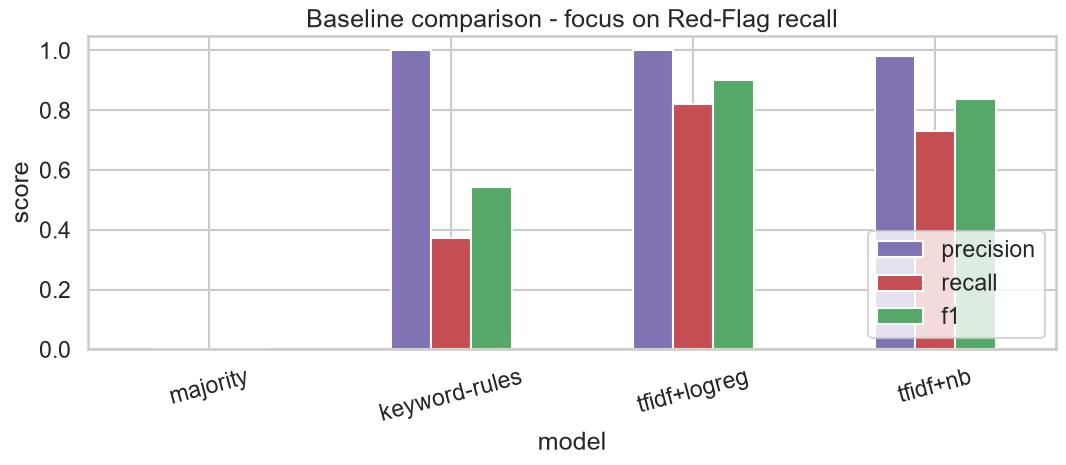

In [6]:
ax = comparison[["precision", "recall", "f1"]].plot(
    kind="bar", figsize=(11, 5), rot=15,
    color=["#8172B3", "#C44E52", "#55A868"])
ax.set_title("Baseline comparison - focus on Red-Flag recall")
ax.set_ylabel("score"); ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

We pick **TF-IDF + Logistic Regression** as the primary baseline (higher recall
and ROC-AUC, plus directly inspectable coefficients for XAI). Naive Bayes is kept as
a comparison model for Goal 3.

In [7]:
primary = models["tfidf+logreg"]
y_pred  = primary.predict(X_test)
y_proba = primary.predict_proba(X_test)[:, 1]

### 2.3 Confusion matrix & error focus (primary model)

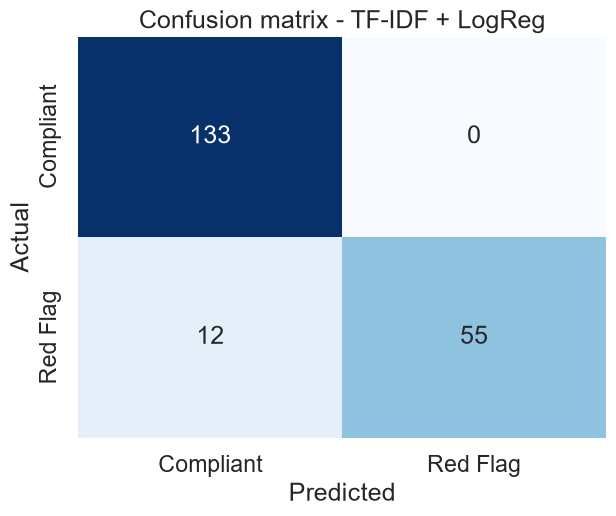

False negatives (missed red flags): 12  <------ most costly!
False positives (over-flagging)   : 0
Miss rate (1 - recall)            : 17.9%


In [8]:
tn, fp, fn, tp = MET.confusion_counts(y_test, y_pred)
cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Compliant", "Red Flag"],
            yticklabels=["Compliant", "Red Flag"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion matrix - TF-IDF + LogReg")
plt.tight_layout(); plt.show()
print(f"False negatives (missed red flags): {fn}  <------ most costly!")
print(f"False positives (over-flagging)   : {fp}")
print(f"Miss rate (1 - recall)            : {MET.miss_rate(y_test, y_pred):.1%}")

### 2.4 ROC & Precision–Recall curves

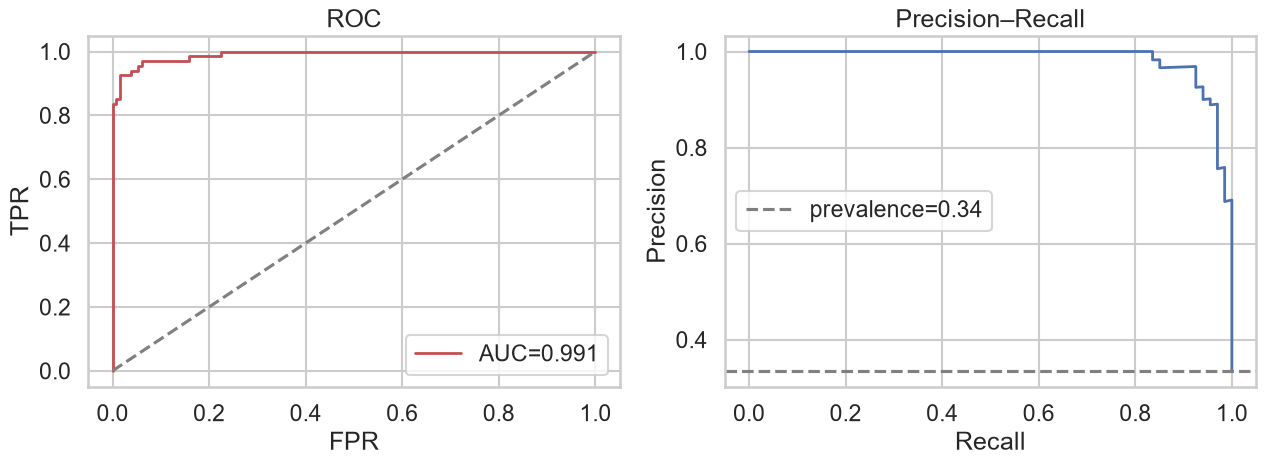

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, color="#C44E52", lw=2, label=f"AUC={roc_auc_score(y_test, y_proba):.3f}")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title("ROC"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].plot(rec, prec, color="#4C72B0", lw=2)
ax[1].axhline(y_test.mean(), ls="--", color="grey", label=f"prevalence={y_test.mean():.2f}")
ax[1].set_title("Precision–Recall"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.show()

### 2.5 What the primary model learned (interpretability preview)

'sentinel.top_terms()' returns the strongest linear coefficients - a cheap sanity
check before the full XAI in Goal 3.

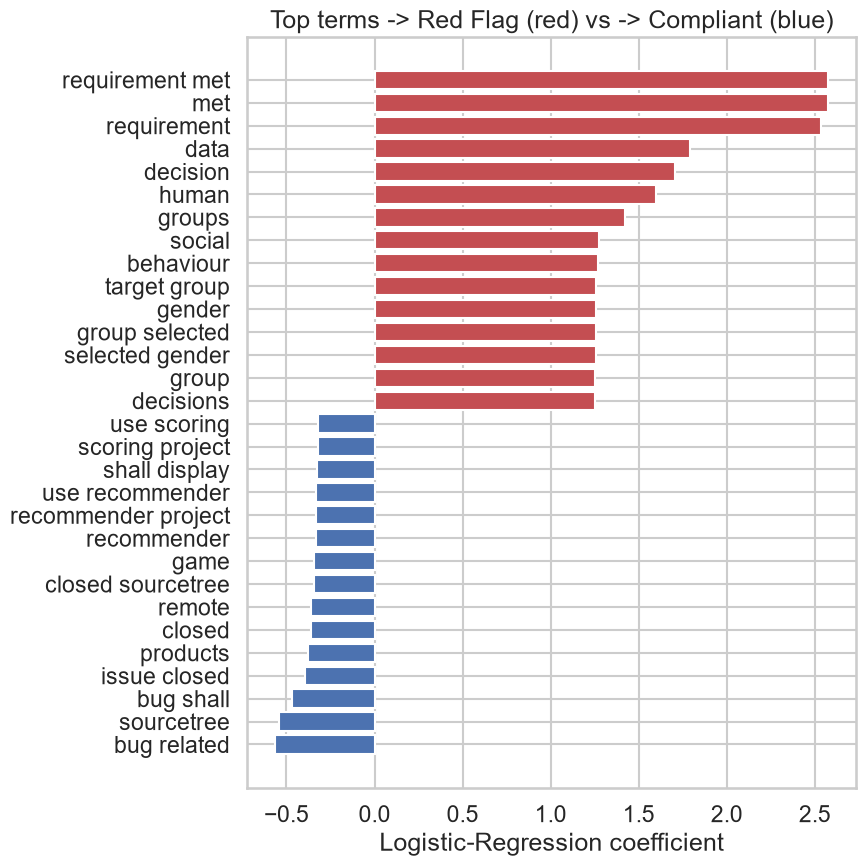

In [10]:
pos, neg = S.top_terms(primary, n=15)
top = pd.concat([neg, pos]).sort_values()

# Choose a color per bar: red if the term pushes toward Red Flag, else blue
colors = []
for v in top.values:
    if v > 0:
        colors.append("#C44E52")
    else:
        colors.append("#4C72B0")

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top.index, top.values, color=colors)
ax.set_title("Top terms -> Red Flag (red) vs -> Compliant (blue)")
ax.set_xlabel("Logistic-Regression coefficient")
plt.tight_layout(); plt.show()

## 3. Risk analysis

Risks of the model **and** the surrounding agent, each with likelihood, impact,
mitigation and **how we test it** (the tests become part of Goal 3's suite).

In [11]:
risks = pd.DataFrame([
 ["R1","False negative - real violation missed","High","High"],
 ["R2","False positive - over-flagging / alarm fatigue","Med","Med"],
 ["R3","Class imbalance (1/3 positives)","High","Med"],
 ["R4","Synthetic-data leakage / shortcut learning","High","High"],
 ["R5","Data / concept drift (new methods, new policies)","Med","High"],
 ["R6","Prompt injection / adversarial evasion","Med","High"],
 ["R7","Automation bias / over-reliance","Med","High"],
 ["R8","Group performance gap (fairness)","Med","Med"],
], columns=["ID","Risk","Likelihood","Impact"])
risks

,ID,Risk,Likelihood,Impact
0,R1,False negative - real violation missed,High,High
1,R2,False positive - over-flagging / alarm fatigue,Med,Med
2,R3,Class imbalance (1/3 positives),High,Med
3,R4,Synthetic-data leakage / shortcut learning,High,High
4,R5,"Data / concept drift (new methods, new policies)",Med,High
5,R6,Prompt injection / adversarial evasion,Med,High
6,R7,Automation bias / over-reliance,Med,High
7,R8,Group performance gap (fairness),Med,Med


**Mitigations & tests (summary).**
R1 optimise threshold for recall + human-in-the-loop → *test:* miss-rate on hold-out & hard cases.
R2 confidence bands + explanations → *test:* precision & dismissed-flag rate.
R3 'class_weight='balanced'', report recall/F1 → *test:* beat majority baseline.
R4 evaluate grounded vs synthetic → *test:* recall gap by 'grounded_flag'.
R5 scheduled retraining + drift monitor → *test:* PSI on inputs, canary set.
R6 treat text as data, adversarial training → *test:* recall drop under perturbation.
R7 always surface reasons + sign-off → *test:* human override-rate audit.
R8 per-group metrics + group-aware thresholds → *test:* equalized-odds gaps (Section 4).

### 3.1 Risk heat-map (likelihood × impact)

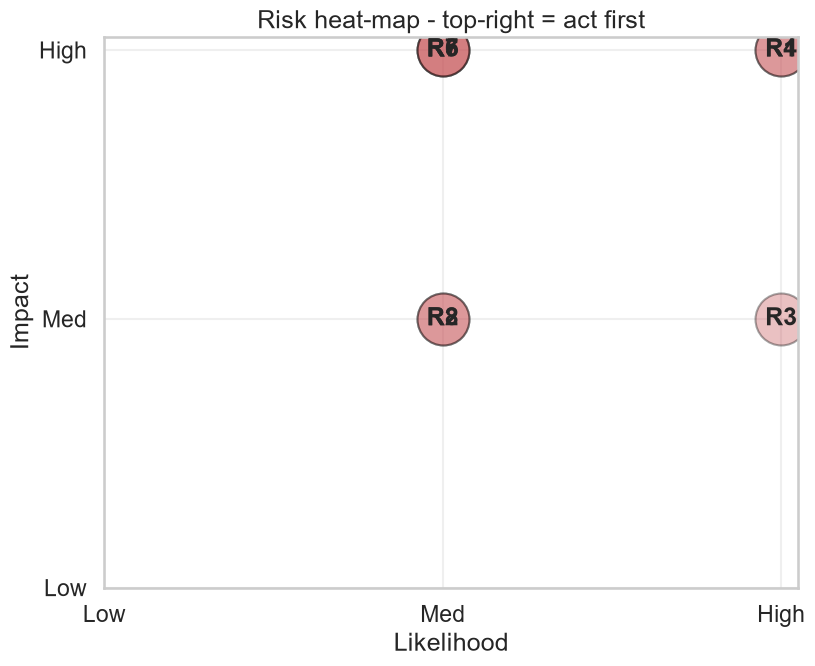

In [12]:
order = {"Low": 0, "Med": 1, "High": 2}
rp = risks.assign(L=risks.Likelihood.map(order), I=risks.Impact.map(order))
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(rp.L, rp.I, s=1400, c="#C44E52", alpha=0.35, edgecolors="black")
for _, r in rp.iterrows():
    ax.annotate(r.ID, (r.L, r.I), ha="center", va="center", fontweight="bold")
ax.set_xticks([0,1,2]); ax.set_xticklabels(["Low","Med","High"])
ax.set_yticks([0,1,2]); ax.set_yticklabels(["Low","Med","High"])
ax.set_xlabel("Likelihood"); ax.set_ylabel("Impact")
ax.set_title("Risk heat-map - top-right = act first"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.2 Risk test - R4: does the model rely on synthetic wording?

In [13]:
fair = fair_frames["tfidf+logreg"]
rf = fair[fair.y_true == 1]

# Recall on the "grounded" proposals (based on a real NFR)
sub = rf[rf.grounded_flag == 1]
if len(sub) > 0:
    recall = (sub.y_pred == 1).mean()
    print("Recall on grounded (real NFR):", round(recall, 3), " n =", len(sub))

# Recall on the fully synthetic proposals
sub = rf[rf.grounded_flag == 0]
if len(sub) > 0:
    recall = (sub.y_pred == 1).mean()
    print("Recall on synthetic         :", round(recall, 3), " n =", len(sub))

Recall on grounded (real NFR): 0.88  n = 25
Recall on synthetic         : 0.786  n = 42


### 3.3 Risk test - R1: threshold vs. missed violations

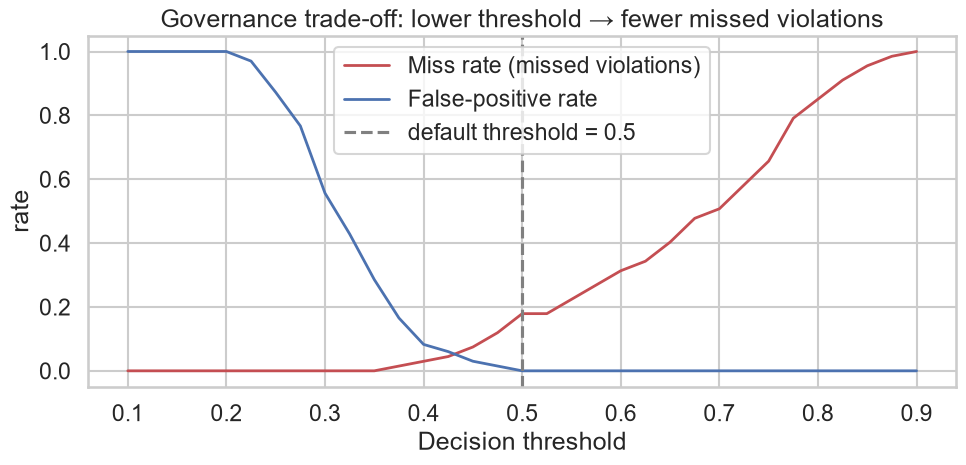

In [14]:
sweep = MET.threshold_sweep(y_test, y_proba)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep.threshold, sweep.miss_rate, color="#C44E52", lw=2, label="Miss rate (missed violations)")
ax.plot(sweep.threshold, sweep.fpr, color="#4C72B0", lw=2, label="False-positive rate")
ax.axvline(0.5, ls="--", color="grey", label="default threshold = 0.5")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("rate")
ax.set_title("Governance trade-off: lower threshold → fewer missed violations")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Fairness analysis

The "individuals" judged here are **proposals**, not people, so fairness is
**procedural**: *does the Sentinel enforce the rules equally well across groups, or
does it let violations slip through for some?* A group with **lower recall** is
under-policed - the compliance analogue of an unfairly treated population, and a
direct hit on our own policy **RAI-03 (Fairness)**.

Metrics come from 'sentinel.metrics.group_metrics' / 'eo_gaps'.

In [15]:
m_issue = MET.group_metrics(fair, "issue_type").round(3)
m_ai    = MET.group_metrics(fair, "ai_method").sort_values("recall_TPR").round(3)
m_gr    = MET.group_metrics(fair, "grounded_flag").round(3)
m_gr.index = m_gr.index.map({0: "synthetic", 1: "grounded"})
m_issue

,n,n_pos,recall_TPR,FPR,precision,selection_rate
issue_type,,,,,,
Bug,167,59,0.814,0.0,1.0,0.287
Suggestion,33,8,0.875,0.0,1.0,0.212


### 4.1 Recall per AI method - are all methods policed equally?

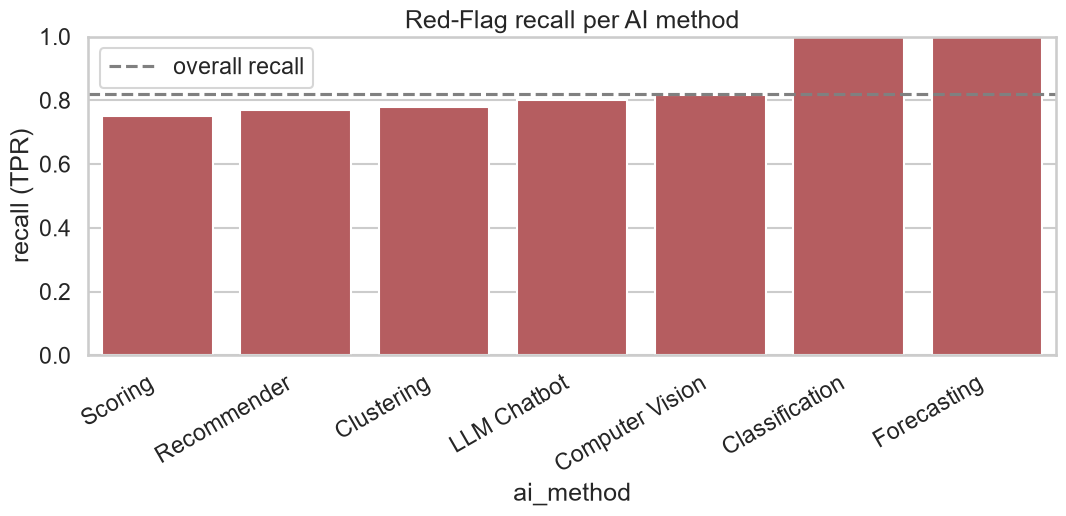

m_ai:
                   n  n_pos  recall_TPR  FPR
ai_method                                  
Scoring          27     12       0.750  0.0
Recommender      36     13       0.769  0.0
Clustering       21      9       0.778  0.0
LLM Chatbot      33     10       0.800  0.0
Computer Vision  33     11       0.818  0.0
Classification   21      4       1.000  0.0
Forecasting      29      8       1.000  0.0


In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(x=m_ai.index, y=m_ai.recall_TPR, color="#C44E52", ax=ax)
ax.axhline((fair.y_pred[fair.y_true == 1]).mean(), ls="--", color="grey", label="overall recall")
ax.set_title("Red-Flag recall per AI method"); ax.set_ylabel("recall (TPR)"); ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right"); ax.legend(); plt.tight_layout(); plt.show()
print("m_ai:\n", m_ai[["n","n_pos","recall_TPR","FPR"]])

### 4.2 Equalized-odds gaps by grouping attribute (smaller = fairer)

,TPR gap,FPR gap,selection-rate gap
issue_type,0.061,0.0,0.075
ai_method,0.250,0.0,0.143
grounded_flag,0.094,0.0,0.691


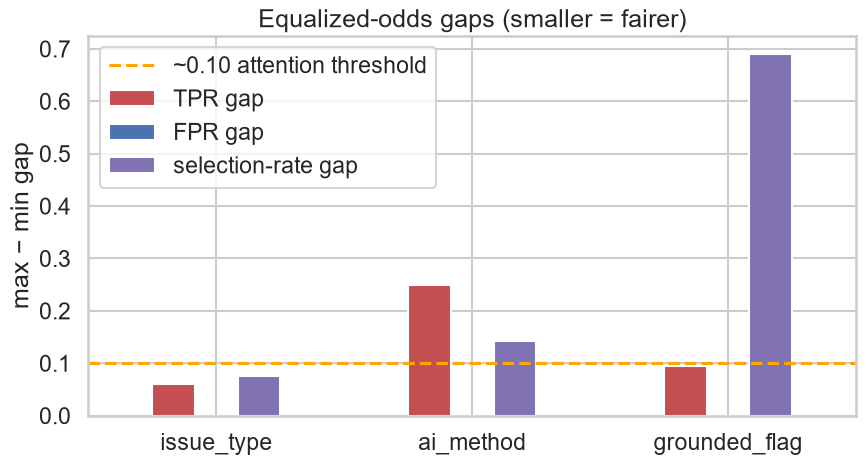

In [17]:
summary = pd.DataFrame({
    "issue_type":    MET.eo_gaps(fair, "issue_type"),
    "ai_method":     MET.eo_gaps(fair, "ai_method"),
    "grounded_flag": MET.eo_gaps(fair, "grounded_flag"),
}).T.round(3)
display(summary)
fig, ax = plt.subplots(figsize=(9, 5))
summary.plot(kind="bar", ax=ax, rot=0, color=["#C44E52", "#4C72B0", "#8172B3"])
ax.axhline(0.10, ls="--", color="orange", label="~0.10 attention threshold")
ax.set_title("Equalized-odds gaps (smaller = fairer)"); ax.set_ylabel("max − min gap")
ax.legend(); plt.tight_layout(); plt.show()

### 4.3 Interpretation

- **Recall is the fairness metric that matters**: a low-recall group is one whose
  violations the agent silently lets through.
- **Grounded vs. synthetic** is the safety-critical slice - it doubles as the
  shortcut-learning check (risk R4). Similar recall on both is reassuring.
- **Small subgroups** (few positives per AI method) make some gaps noisy; Goal 3
  confirms them with **stratified cross-validation** and considers group-aware
  thresholds if a gap persists.
- Feeds straight back into policy **RAI-03 (Fairness)**.

## 5. Reusable code, artifacts & tests (hand-off to Goal 3)

Everything above runs on the importable, unit-tested **'sentinel/'** package:

| Module | Responsibility |
|---|---|
| 'sentinel/data.py' | locate/load proposals, target, stratified split |
| 'sentinel/baselines.py' | majority + keyword baselines |
| 'sentinel/models.py' | the 2 ML models, save/load, top-terms |
| 'sentinel/metrics.py' | scores, confusion, threshold sweep, fairness |
| 'sentinel/pipeline.py' | 'build_artifacts()' - train + evaluate + persist |

**Persisted artifacts** ('artifacts/'): 'model_tfidf_logreg.joblib',
'model_tfidf_nb.joblib', 'split.joblib', 'test_predictions_logreg.csv', 'scores.csv'
- Goal 3 loads these for XAI without retraining.

**Tests:** 'tests/test_sentinel.py' already exercises every module. Run:
'''bash
pytest -q --cov=sentinel --cov-report=term-missing
'''
The starter suite reaches **~99 % coverage**, so Goal 3's **≥ 80 %** target is met
from the outset and only needs weakness/adversarial tests added.

## 6. Conclusion - Goal 2

- **Baseline:** two transparent ML models (LogReg primary, NB comparison) clearly
  beat majority/keyword baselines; we optimise & report **Red-Flag recall** and
  handle the 1/3 imbalance with balanced class weights.
- **Risk:** eight risks assessed on likelihood × impact; the act-first cluster is
  **R1 false negatives, R4 synthetic leakage, R5 drift**, each with a concrete,
  repeatable test.
- **Fairness:** procedural framing - per-group recall/FPR and equalized-odds gaps
  over issue type, AI method and grounding; tied back to policy **RAI-03**.
- **Engineering:** logic factored into a tested package with saved model artifacts,
  so **Goal 3 (model analysis · XAI · tests ≥ 80 % coverage)** can start immediately.